# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')

In [3]:
X = df.drop(['dayofweek'], axis=1)
y = df['dayofweek']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [4]:
y.value_counts()

dayofweek
3    396
6    356
1    274
5    271
2    149
0    136
4    104
Name: count, dtype: int64

In [5]:
y_train.value_counts()

dayofweek
3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: count, dtype: int64

In [6]:
y_test.value_counts()

dayofweek
3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: count, dtype: int64

In [7]:
distr = pd.DataFrame({
    'Original': y.value_counts(normalize=True).sort_index(),
    'Train': y_train.value_counts(normalize=True).sort_index(),
    'Test': y_test.value_counts(normalize=True).sort_index()
})
distr

,Original,Train,Test
dayofweek,,,
0,0.080664,0.080861,0.079882
1,0.162515,0.162463,0.162722
2,0.088375,0.088279,0.088757
3,0.234875,0.234421,0.236686
4,0.061684,0.061573,0.062130
5,0.160735,0.160979,0.159763
6,0.211151,0.211424,0.210059


<Axes: xlabel='dayofweek'>

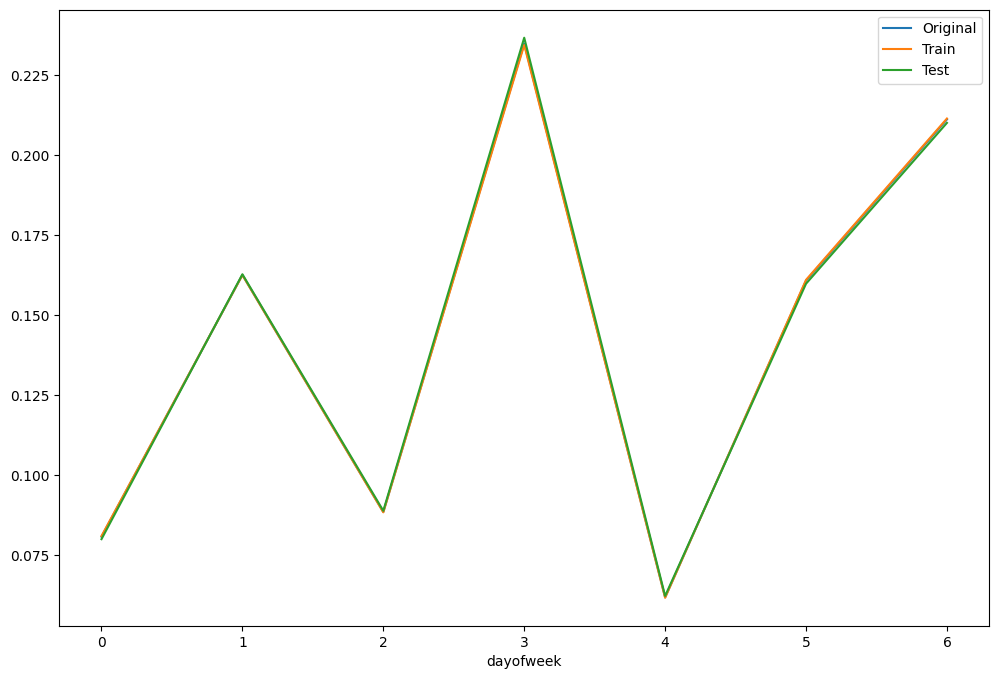

In [8]:
distr.plot(figsize=(12,8))

## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [9]:
model = LogisticRegression(random_state=21, fit_intercept=False, solver="liblinear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


0.6153846153846154

In [10]:
model = LogisticRegression(random_state=21, fit_intercept=False, solver="liblinear")
model.fit(X, y)
y_pred_old = model.predict(X)
acc_old = accuracy_score(y, y_pred_old)
acc_old

/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


0.6215895610913404

In [11]:
diff = abs(acc - acc_old)
diff

0.006204945706725029

### b. SVM

In [12]:
model = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel='linear'))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.6301775147928994

In [13]:
model = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel='linear'))
model.fit(X, y)
y_pred_old = model.predict(X)
acc_old = accuracy_score(y, y_pred_old)
acc_old

0.6115065243179122

In [14]:
diff = abs(acc - acc_old)
diff

0.018670990474987215

### c. Decision tree

In [15]:
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.5295857988165681

In [16]:
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X, y)
y_pred_old = model.predict(X)
acc_old = accuracy_score(y, y_pred_old)
acc_old

0.5516014234875445

In [17]:
diff = abs(acc - acc_old)
diff

0.022015624670976397

### d. Random forest

In [18]:
model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.9289940828402367

In [19]:
model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model.fit(X, y)
y_pred_old = model.predict(X)
acc_old = accuracy_score(y, y_pred_old)
acc_old

1.0

In [20]:
diff = abs(acc - acc_old)
diff

0.07100591715976334

Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous?  
No  
**RandomForest**

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [21]:
model = LogisticRegression(random_state=21, fit_intercept=False, solver="liblinear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


0.6153846153846154

In [22]:
cross_val = cross_val_score(model, X_train, y_train, cv = 10)
cross_val.mean()

/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/boriskov/.local/pipx/venvs/jupyterlab/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is d

np.float64(0.5815975677169707)

In [23]:
cross_val.std()

np.float64(0.025322132907253592)

### b. SVM

In [24]:
model = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel='linear'))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.6301775147928994

In [25]:
cross_val = cross_val_score(model, X_train, y_train, cv = 10)
cross_val.mean()

np.float64(0.5682918739635158)

In [26]:
cross_val.std()

np.float64(0.0372674056353565)

### c. Decision tree

In [27]:
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.5295857988165681

In [28]:
cross_val = cross_val_score(model, X_train, y_train, cv = 10)
cross_val.mean()

np.float64(0.5088944168048645)

In [29]:
cross_val.std()

np.float64(0.031903139495514356)

### d. Random forest

In [30]:
model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.9289940828402367

In [31]:
cross_val = cross_val_score(model, X_train, y_train, cv = 10)
cross_val.mean()

np.float64(0.9176561636263129)

In [32]:
cross_val.std()

np.float64(0.02159583796321821)

## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [33]:
best_accuracy = cross_val
for n in range(25,100):
    for depth in range(10,35):
        rforest = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=21)
        new_accuracy = cross_val_score(rforest, X_train, y_train, cv = 10)
        if new_accuracy.mean() > best_accuracy.mean():
            best_params = (n,depth)
            best_accuracy = new_accuracy 
print(new_accuracy)
best_params

[0.8962963  0.95555556 0.91851852 0.93333333 0.91111111 0.8962963
 0.91851852 0.9037037  0.91791045 0.90298507]


(92, 31)

In [ ]:
# best_params = (92,31)

In [34]:
rnf = RandomForestClassifier(n_estimators=best_params[0], max_depth=best_params[1], random_state=21)
rnf.fit(X_train, y_train)
y_pred_rnf = rnf.predict(X_test)
acc_rnf = accuracy_score(y_test, y_pred_rnf)
acc_rnf

0.9378698224852071

In [35]:
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rnf.feature_importances_
})
feature_imp = feature_imp.sort_values(['importance']).tail(10)

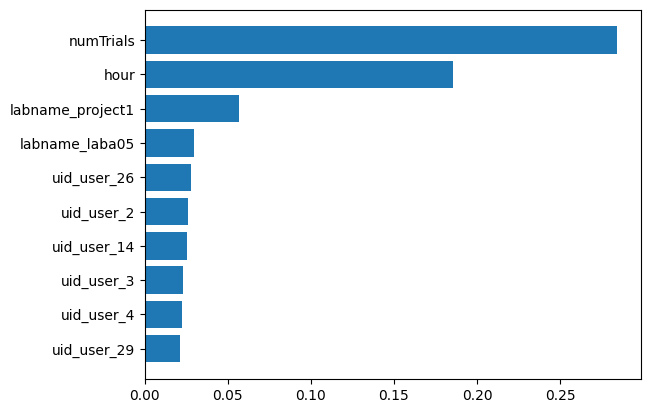

In [36]:
plt.barh(feature_imp['feature'], feature_imp['importance'])
plt.show()

In [ ]:
joblib.dump(rnf, 'rnf.pkl')

['rnf.pkl']

In [38]:
l_rnf = joblib.load('rnf.pkl')

In [39]:
y_pred = l_rnf.predict(X_test)
accuracy_score(y_pred, y_test)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.